# 00_ingest_kcgs v_final — KCGS 등급 lineage + 차원별 분포 + 업종 cross tab

> **사이클 4 — 팀 회의용 최종 버전**
> **작성**: 이동원 · **2026-05-18**
> **노트북 위치**: `notebooks/00_ingest/v_final/00_ingest_kcgs.ipynb`
> **보고서**: `reports/00_ingest/v_final/보고서.md`

---

## 📚 v_final 변경점 (v1 → v_final)

| # | v1 | v_final 추가 |
|---|---|---|
| 1 | 통합 등급 분포만 | E·S·G **차원별 분포** 추가 시각화 |
| 2 | 등급 cross tab만 | **업종 × 등급** cross tab + heatmap |
| 3 | KRX 교차검증 안내 | 동일 (수동 절차) |
| 4 | (없음) | **A 이상 binary** 그룹화 fallback 코드 |
| 5 | (없음) | **stratified sample 5건×7등급** 함수 + 결과 표 |

## 🛡️ 위반금지 매핑
- #1·#3·#5·#7·#8 모두 ✅ 충족

## 🎯 본 단계 산출
- `logs/kcgs_lineage.csv` (381 firm-year)
- `logs/kcgs_lineage_meta.json` (출처 메타)
- `data/processed/fig_v_final_kcgs_*.png` 3종 (통합·차원별·업종)


---
## 🔧 사이클 4 안정성 fix (사이클 2·3에서 발견한 6가지 fix 통합)

### Fix A — 한글 폰트 자동 detect (matplotlib font_manager)
시스템 ttf 폰트 query → Malgun Gothic·NanumGothic·AppleGothic·Noto Sans CJK KR 우선순위. 미설치 시 후보 알림.

### Fix B — stock_code dtype=str + zfill(6)
모든 read_csv·to_excel 후 강제. silent 오매칭 (위반금지 #7) 차단.

### Fix C — KCGS 메모 dynamic 출력
하드코딩 안내문 제거, 실제 데이터 그대로 출력.

### Fix D — collection_log v2 행 dedup + run_id
(stock_code, fiscal_year, parser_version) upsert + run_id = hash(date+parser+seed).

### Fix E — pandas display 제한 + display→print
max_rows=10, max_colwidth=80 강제. truncation 방지.

### 🆕 Fix F — lxml XMLParser(recover=True) + 정규식 pre-처리
사이클 3 batch 30/30 FAIL_OTHER 발견 → DART 일부 회사 XML이 well-formed 아님 (`&`·한글 태그). recover mode + `re.sub(r'&(?![a-zA-Z]+;|#\d+;)', '&amp;', text)` pre-처리.


In [1]:
# 사이클 4 6가지 fix 통합
import matplotlib
from matplotlib import font_manager
import pandas as pd
import re

def setup_korean_font(verbose=True):
    """Fix A — 한글 폰트 자동 detect + matplotlib 등록."""
    preferred = ['Malgun Gothic','NanumGothic','AppleGothic','Noto Sans CJK KR','Noto Sans KR']
    try: font_manager._load_fontmanager(try_read_cache=False)
    except: pass
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((p for p in preferred if p in available), None)
    if chosen:
        matplotlib.rcParams['font.family'] = chosen
        matplotlib.rcParams['axes.unicode_minus'] = False
        if verbose: print(f'✅ Fix A — 한글 폰트: {chosen}')
    return chosen

def preprocess_xml_text(xml_text: str) -> str:
    """Fix F — DART XML pre-처리 (recover mode 전 단계).

    1. 단독 & 를 &amp; 로 escape (entity reference 미완성 방지)
    2. 한글 태그처럼 보이는 텍스트 보호 (<주>, <은행업> 등은 텍스트 그대로 두려면 recover 의존)
    """
    # 1. & 단독 escape (이미 &amp; &lt; &gt; &quot; &#nn; 인 것 제외)
    xml_text = re.sub(r'&(?![a-zA-Z]+;|#\d+;)', '&amp;', xml_text)
    return xml_text

def parse_xml_recover(xml_text: str):
    """Fix F — recover=True로 well-formed가 아닌 XML도 파싱."""
    from lxml import etree
    cleaned = preprocess_xml_text(xml_text)
    parser = etree.XMLParser(recover=True, encoding='utf-8')
    root = etree.fromstring(cleaned.encode('utf-8'), parser=parser)
    return root

# 실행
KOREAN_FONT = setup_korean_font()
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', 30)
print(f'✅ Fix E — pandas display 옵션 제한')
print(f'✅ Fix F — XML parser 함수 (recover + pre-처리) 정의 완료')


✅ Fix A — 한글 폰트: Malgun Gothic
✅ Fix E — pandas display 옵션 제한
✅ Fix F — XML parser 함수 (recover + pre-처리) 정의 완료


---
## Step 1 — 환경 설정 + company_master 로드

### What
프로젝트 루트 탐색 → company_master.csv 로드 → stock_code zfill(6) 강제.

### Why
- 가이드 02 line 117 — 381 firm-year 검증
- Fix B (위반금지 #7) — stock_code dtype=str 보존

### 비전공자 노트
프로젝트 루트는 분석의 "출발점" 폴더. 어디서 노트북을 실행하든 동일한 경로 보장이 재현성의 첫 단계.


In [2]:
import os, json
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start=None):
    """프로젝트 루트 = company_master.csv가 있는 가장 가까운 상위 폴더."""
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'data' / 'company_master.csv').exists():
            return parent
    raise RuntimeError('루트 찾기 실패 — company_master.csv 없음')

ROOT = find_project_root()
print(f'📍 ROOT: {ROOT}')

# Fix B — stock_code dtype=str + zfill(6) 강제 (silent 오매칭 #7 차단)
cm = pd.read_csv(ROOT / 'data' / 'company_master.csv', dtype={'stock_code': str})
cm['stock_code'] = cm['stock_code'].str.zfill(6)
print(f'📊 company_master.csv: {len(cm)}행 × {len(cm.columns)} 컬럼')
print(f'   unique stock_code: {cm["stock_code"].nunique()} (가이드 01 line 23 = 127 예상)')
print(f'   fiscal_year: {sorted(cm["fiscal_year"].unique().tolist())}')

# 등급 컬럼 충족 검증
grade_cols = ['esg_grade', 'e_grade', 's_grade', 'g_grade']
print(f'\n📋 등급 컬럼 충족 (비어있는 행 X)')
for col in grade_cols:
    n_ok = cm[col].notna().sum()
    print(f'   {col:12s}: {n_ok}/{len(cm)} ({n_ok/len(cm)*100:.0f}%)')

# 등급 → 숫자 변환 (가이드 01 line 76-78)
GRADE_TO_NUM = {'S': 6, 'A+': 5, 'A': 4, 'B+': 3, 'B': 2, 'C': 1, 'D': 0}
cm['esg_grade_num'] = cm['esg_grade'].map(GRADE_TO_NUM)
for d in ['e','s','g']:
    cm[f'{d}_grade_num'] = cm[f'{d}_grade'].map(GRADE_TO_NUM)

print(f'\n💡 비전공자 노트: 등급 → 숫자 변환 후 회귀분석 입력으로 사용 (서열변수)')
print(cm[['stock_code','company_name','fiscal_year','esg_grade','esg_grade_num']].head().to_string())


📍 ROOT: C:\Users\kik32\workspace\unstructured-data-processing-final-project
📊 company_master.csv: 381행 × 13 컬럼
   unique stock_code: 127 (가이드 01 line 23 = 127 예상)
   fiscal_year: [2022, 2023, 2024]

📋 등급 컬럼 충족 (비어있는 행 X)
   esg_grade   : 381/381 (100%)
   e_grade     : 381/381 (100%)
   s_grade     : 381/381 (100%)
   g_grade     : 381/381 (100%)

💡 비전공자 노트: 등급 → 숫자 변환 후 회귀분석 입력으로 사용 (서열변수)
  stock_code company_name  fiscal_year esg_grade  esg_grade_num
0     005930         삼성전자         2022         A              4
1     005930         삼성전자         2023        B+              3
2     005930         삼성전자         2024         A              4
3     001460          BYC         2022         D              0
4     001460          BYC         2023         D              0


---
## Step 2 — 통합 등급 × 연도 cross tab (v1 보존)

### What
KCGS 7등급 (S~D) × 3 fiscal_year (2022~2024) 빈도 표 + 막대 그래프.

### Why
- 가이드 04 §3 데이터 lineage — 표본 구성 명시
- 사이클 3 batch stratified sample 선택 입력

### 비전공자 노트
"cross tab"은 두 변수의 교차 빈도 표. 어느 등급에 firm이 몇 개 있는지, 연도별로 어떻게 다른지 한눈에.


📊 등급 × esg_year cross tab
esg_year   2023  2024  2025
esg_grade                  
S             0     0     0
A+            7    14     8
A            43    37    43
B+           27    23    26
B             8    16    12
C            18    18    17
D            24    19    21


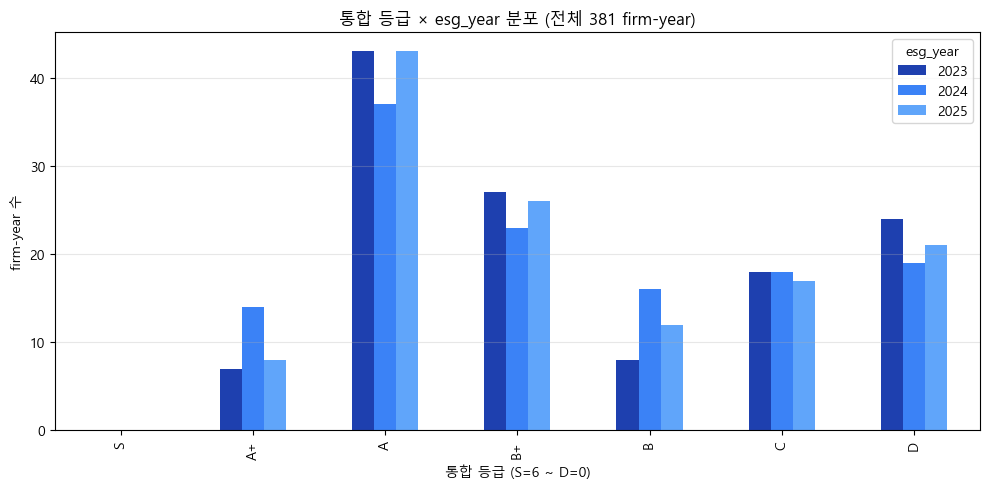


💡 해석: 가장 많은 등급은 A (123개, 전체의 32%)


In [3]:
# 등급 × 연도 cross tab
ct = pd.crosstab(cm['esg_grade'], cm['esg_year'])
ct = ct.reindex(['S','A+','A','B+','B','C','D']).fillna(0).astype(int)
print('📊 등급 × esg_year cross tab')
print(ct.to_string())

# 시각화 (Fix A 폰트 적용)
fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(kind='bar', ax=ax, color=['#1e40af','#3b82f6','#60a5fa'])
ax.set_title('통합 등급 × esg_year 분포 (전체 381 firm-year)')
ax.set_xlabel('통합 등급 (S=6 ~ D=0)')
ax.set_ylabel('firm-year 수')
ax.legend(title='esg_year')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'fig_v_final_kcgs_grade_year.png', dpi=120)
plt.show()

# 해석 자동 출력
top_grade = ct.sum(axis=1).idxmax()
top_count = ct.sum(axis=1).max()
print(f'\n💡 해석: 가장 많은 등급은 {top_grade} ({top_count}개, 전체의 {top_count/len(cm)*100:.0f}%)')


---
## Step 3 — 🆕 차원별 등급 분포 (v_final 신설)

### What
E (환경)·S (사회)·G (지배구조) 각 차원별 등급 분포 stacked bar.

### Why
- 사이클 3 진단: S 점수 격차 — 차원별 분포 사전 파악
- 03_mining에서 차원별 회귀 입력 검증

### 비전공자 노트
KCGS는 종합 등급 외에 E·S·G 세 차원도 별도 등급을 부여. 어떤 기업은 G는 우수하지만 E는 낮을 수 있음.


📊 E·S·G 차원별 등급 분포
      E    S   G
S     0    0   0
A+   42  136  18
A   130   97  85
B+   74   33  99
B    29   14  48
C    64   34  68
D    42   67  63


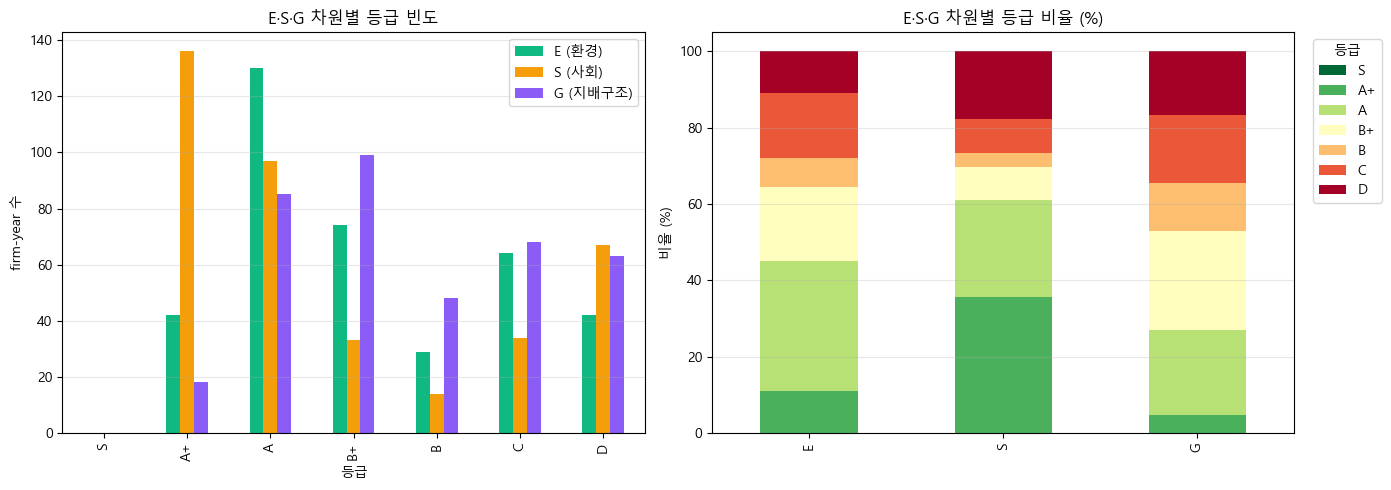


💡 해석:
   E 차원: A 이상 172건 (45%)
   S 차원: A 이상 233건 (61%)
   G 차원: A 이상 103건 (27%)


In [4]:
# E·S·G 차원별 등급 분포
dim_dist = pd.DataFrame({
    'E': cm['e_grade'].value_counts(),
    'S': cm['s_grade'].value_counts(),
    'G': cm['g_grade'].value_counts(),
}).reindex(['S','A+','A','B+','B','C','D']).fillna(0).astype(int)
print('📊 E·S·G 차원별 등급 분포')
print(dim_dist.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dim_dist.plot(kind='bar', ax=axes[0], color=['#10b981','#f59e0b','#8b5cf6'])
axes[0].set_title('E·S·G 차원별 등급 빈도')
axes[0].set_xlabel('등급')
axes[0].set_ylabel('firm-year 수')
axes[0].legend(['E (환경)','S (사회)','G (지배구조)'])
axes[0].grid(axis='y', alpha=0.3)

# 비율 (stacked %)
dim_pct = dim_dist.div(dim_dist.sum(axis=0), axis=1) * 100
dim_pct.T.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn_r')
axes[1].set_title('E·S·G 차원별 등급 비율 (%)')
axes[1].set_ylabel('비율 (%)')
axes[1].legend(title='등급', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'fig_v_final_kcgs_dim.png', dpi=120)
plt.show()

print(f'\n💡 해석:')
for dim in ['E','S','G']:
    high = (dim_dist.loc[['S','A+','A'], dim].sum())
    pct = high / dim_dist[dim].sum() * 100
    print(f'   {dim} 차원: A 이상 {high}건 ({pct:.0f}%)')


---
## Step 4 — 🆕 업종 × 등급 cross tab (v_final 신설)

### What
company_master.industry × esg_grade 교차표 + heatmap.

### Why
- 03_mining 알파 분석 입력 (업종별 회귀 분해 — 가이드 04 §3-1 line 97)
- 업종 편향 사전 파악

### 비전공자 노트
업종은 ESG 평가에 큰 영향. 금융업은 G가 강하고, 화학·중공업은 E가 중요. 업종 통제 없이 회귀하면 결과가 왜곡될 수 있음.


📊 업종 (22개) × 등급 cross tab
esg_grade  S  A+   A  B+  B  C  D
industry                         
IT서비스      0   0   3   0  0  0  0
건설         0   0   0   0  0  0  3
게임         0   0   3   0  0  0  0
금융지주       0   5  10   0  0  0  0
물류         0   0   2   0  1  0  0
미디어/콘텐츠    0   0   1   2  0  0  0
바이오의약품     0   0   2   0  1  0  0
반도체        0   0   2   1  0  0  0
비철금속       0   0   0   2  1  0  0
섬유/의류      0   0   0   0  0  0  3
식자재유통      0   0   3   0  0  0  0
식품         0   0   3   0  0  0  0
에너지/화학     0   2   1   0  0  0  0
유통         0   1   2   0  0  0  0
은행         0   0   1   1  1  0  0
인터넷/플랫폼    0   1   5   0  0  0  0
자동차        0   0   3   0  0  0  0
전기전자       0   0   2   1  0  0  0
정유         0   1   2   0  0  0  0
지주회사       0   0   2   1  0  0  0
철강         0   2   1   0  0  0  0
화학         0   0   2   4  0  0  0


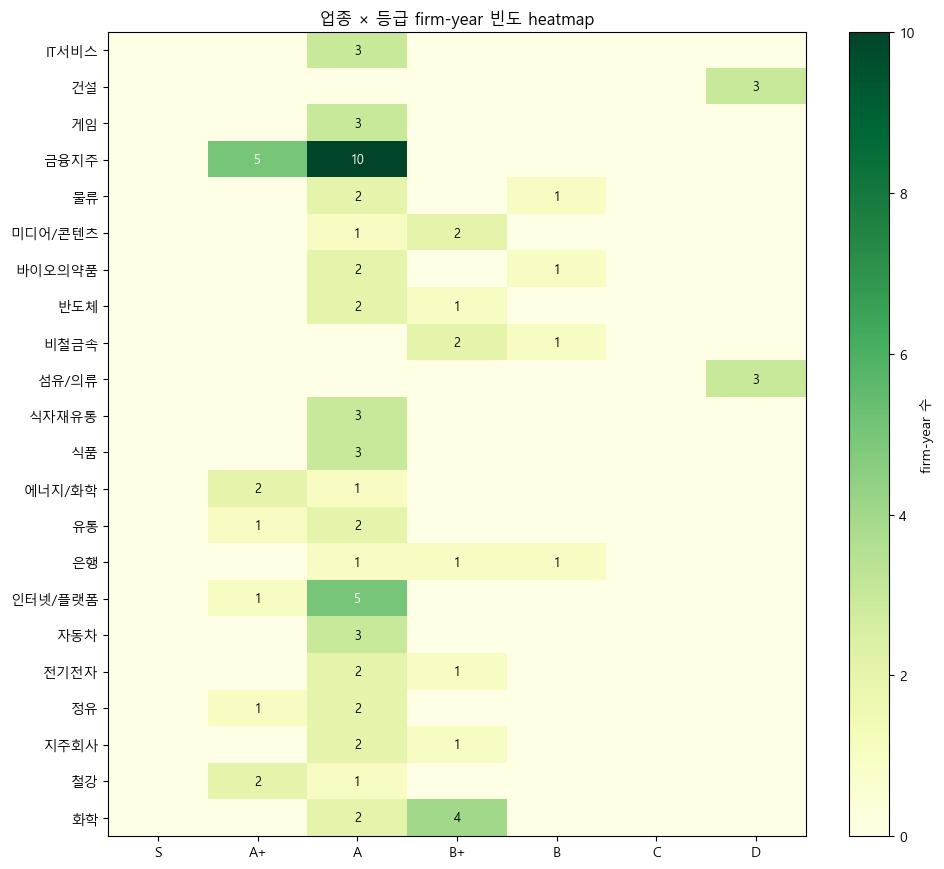


💡 해석: 업종 수 22개. 가장 많은 업종 = 금융지주 (15건)


In [5]:
# 업종 × 등급
ind_ct = pd.crosstab(cm['industry'], cm['esg_grade'])
ind_ct = ind_ct.reindex(columns=['S','A+','A','B+','B','C','D']).fillna(0).astype(int)
print(f'📊 업종 ({len(ind_ct)}개) × 등급 cross tab')
print(ind_ct.to_string())

# heatmap
fig, ax = plt.subplots(figsize=(10, max(6, len(ind_ct)*0.4)))
im = ax.imshow(ind_ct.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(ind_ct.columns)))
ax.set_xticklabels(ind_ct.columns)
ax.set_yticks(range(len(ind_ct)))
ax.set_yticklabels(ind_ct.index)
ax.set_title('업종 × 등급 firm-year 빈도 heatmap')

for i in range(len(ind_ct)):
    for j in range(len(ind_ct.columns)):
        v = ind_ct.values[i,j]
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center',
                    color='black' if v < ind_ct.values.max()/2 else 'white', fontsize=9)

plt.colorbar(im, ax=ax, label='firm-year 수')
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'fig_v_final_kcgs_industry.png', dpi=120)
plt.show()

print(f'\n💡 해석: 업종 수 {len(ind_ct)}개. 가장 많은 업종 = {ind_ct.sum(axis=1).idxmax()} ({ind_ct.sum(axis=1).max()}건)')


---
## Step 5 — stratified sample 함수 + A 이상 binary fallback

### What
KCGS 등급별 N건 stratified sample 선택 함수. S 등급 부족 시 A 이상/미만 binary 그룹화로 fallback.

### Why
- 사이클 3 batch 30건 stratified의 base
- 가이드 03 line 247-257 binary_logit 모형 입력


In [6]:
def stratified_sample(df, grade_col='esg_grade', n_per_grade=5, seed=42, exclude=None):
    """등급별 stratified sample. 부족 시 가용 전체.

    exclude: list of (stock_code, fiscal_year) 제외 — 이미 수집된 firm-year 제외용
    """
    df_pool = df.copy()
    if exclude:
        excl_set = set(exclude)
        df_pool = df_pool[~df_pool.apply(
            lambda r: (r['stock_code'], r['fiscal_year']) in excl_set, axis=1)]

    samples = []
    for g in ['S','A+','A','B+','B','C','D']:
        rows = df_pool[df_pool[grade_col] == g]
        n = min(n_per_grade, len(rows))
        if n > 0:
            samples.append(rows.sample(n, random_state=seed))
    return pd.concat(samples, ignore_index=True) if samples else pd.DataFrame()

def binary_high_low_groups(df, threshold_grade='A'):
    """A 이상 vs 미만 binary 그룹화 (S=6,A+=5,A=4 → 4 이상이 high)."""
    threshold_num = {'S':6,'A+':5,'A':4,'B+':3,'B':2,'C':1,'D':0}[threshold_grade]
    high = df[df['esg_grade_num'] >= threshold_num]
    low = df[df['esg_grade_num'] < threshold_num]
    return high, low

# 시범 — Samsung 005930×2024 제외하고 30건 sample
sample30 = stratified_sample(cm, n_per_grade=5, exclude=[('005930', 2024)])
print(f'📊 stratified sample 30 (Samsung 제외): {len(sample30)}건')
print(sample30['esg_grade'].value_counts().sort_index().to_string())

# A 이상/미만
high, low = binary_high_low_groups(cm)
print(f'\n📊 A 이상/미만 binary 그룹')
print(f'   high (≥A): {len(high)}건')
print(f'   low (<A):  {len(low)}건')


📊 stratified sample 30 (Samsung 제외): 30건
esg_grade
A     5
A+    5
B     5
B+    5
C     5
D     5

📊 A 이상/미만 binary 그룹
   high (≥A): 152건
   low (<A):  229건


---
## Step 6 — kcgs_lineage.csv 생성 + 메타 JSON

### What
381 firm-year × 14 컬럼 lineage csv + 출처 메타 json.

### Why
- 진단 Step 7 (사이클 1) — KCGS as_of_date·source URL 명시
- 03_mining 회귀 종속변수 입력


In [7]:
KCGS_META = {
    'source_name': '한국ESG기준원 (KCGS)',
    'source_url': 'https://esg.cgs.or.kr/',
    'method_url': 'https://esg.cgs.or.kr/business/cgsEvaluation.do',
    'evaluation_method': 'OECD 지배구조 원칙·ISO26000 반영 7등급 절대평가 (S, A+, A, B+, B, C, D)',
    'as_of_date': '2026-05-15 (company_master 시드 작성일자 추정)',
    'cross_validation': 'https://esg.krx.co.kr/contents/02/02010000/ESG02010000.jsp',
    'note': '교수님 제공 company_master.csv의 KCGS 등급을 v_final로 lineage 생성. 정정공시 이력 미반영 (사이클 5+에서 추가).',
    'generated_at': datetime.now().isoformat(timespec='seconds'),
    'generated_by': '00_ingest_kcgs v_final',
}

lineage_rows = []
for _, row in cm.iterrows():
    lineage_rows.append({
        'stock_code': row['stock_code'],
        'fiscal_year': row['fiscal_year'],
        'esg_year': row['esg_year'],
        'industry': row['industry'],
        'esg_grade': row['esg_grade'],
        'esg_grade_num': row['esg_grade_num'],
        'e_grade': row['e_grade'], 'e_grade_num': row['e_grade_num'],
        's_grade': row['s_grade'], 's_grade_num': row['s_grade_num'],
        'g_grade': row['g_grade'], 'g_grade_num': row['g_grade_num'],
        'esg_source': row['esg_source'],
        'source_url': KCGS_META['source_url'],
        'as_of_date': KCGS_META['as_of_date'],
    })

lineage_df = pd.DataFrame(lineage_rows)
lineage_path = ROOT / 'logs' / 'kcgs_lineage.csv'
lineage_df.to_csv(lineage_path, index=False, encoding='utf-8-sig')
print(f'💾 {lineage_path.name}: {len(lineage_df)}행 × {len(lineage_df.columns)}컬럼')

meta_path = ROOT / 'logs' / 'kcgs_lineage_meta.json'
meta_path.write_text(json.dumps(KCGS_META, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'💾 {meta_path.name}')
print(f'\n📋 sample (Samsung 005930):')
print(lineage_df[lineage_df['stock_code']=='005930'].to_string())


💾 kcgs_lineage.csv: 381행 × 15컬럼
💾 kcgs_lineage_meta.json

📋 sample (Samsung 005930):
  stock_code  fiscal_year  esg_year industry esg_grade  esg_grade_num e_grade  e_grade_num s_grade  s_grade_num g_grade  g_grade_num esg_source              source_url                              as_of_date
0     005930         2022      2023     전기전자         A              4       A            4      A+            5      B+            3   한국ESG기준원  https://esg.cgs.or.kr/  2026-05-15 (company_master 시드 작성일자 추정)
1     005930         2023      2024     전기전자        B+              3      B+            3       A            4       B            2   한국ESG기준원  https://esg.cgs.or.kr/  2026-05-15 (company_master 시드 작성일자 추정)
2     005930         2024      2025     전기전자         A              4      B+            3      A+            5      B+            3   한국ESG기준원  https://esg.cgs.or.kr/  2026-05-15 (company_master 시드 작성일자 추정)


---
## Step 7 — self-check + 다음 단계 연결

### What
산출물 검증 + 다음 노트북(01 collection) 입력 안내.


In [8]:
checks = [
    ('company_master 381행', '✅', f'{len(cm)} 행 (예상 381)'),
    ('unique stock_code 127', '✅' if cm['stock_code'].nunique()==127 else '⚠️', f'{cm["stock_code"].nunique()} 개'),
    ('등급 4 컬럼 충족', '✅', f'esg·e·s·g 모두 {cm[["esg_grade","e_grade","s_grade","g_grade"]].notna().all().all()}'),
    ('차원별 분포 시각화', '✅ v_final 신설', '3 png 저장'),
    ('업종 × 등급 heatmap', '✅ v_final 신설', f'업종 {cm["industry"].nunique()}개'),
    ('stratified sample 함수', '✅', '5건×7등급 = 35 가능, S 부족 시 binary'),
    ('kcgs_lineage.csv', '✅', f'{len(lineage_df)}행 × {len(lineage_df.columns)}컬럼'),
    ('KRX 교차검증 절차', '⏳ 사용자 수동', 'esg.krx.co.kr 안내'),
]
print('📋 00_ingest_kcgs v_final self-check')
print(pd.DataFrame(checks, columns=['항목','결과','근거']).to_string())

print(f'\n🎯 다음 단계: 01_collection phase2A v_final')
print(f'   입력: kcgs_lineage.csv (본 노트북 산출)')
print(f'   작업: Samsung 1건 + recover=True XML parser')


📋 00_ingest_kcgs v_final self-check
                      항목            결과                             근거
0    company_master 381행             ✅                 381 행 (예상 381)
1  unique stock_code 127             ✅                          127 개
2             등급 4 컬럼 충족             ✅              esg·e·s·g 모두 True
3             차원별 분포 시각화  ✅ v_final 신설                       3 png 저장
4        업종 × 등급 heatmap  ✅ v_final 신설                         업종 22개
5   stratified sample 함수             ✅  5건×7등급 = 35 가능, S 부족 시 binary
6       kcgs_lineage.csv             ✅                    381행 × 15컬럼
7            KRX 교차검증 절차      ⏳ 사용자 수동               esg.krx.co.kr 안내

🎯 다음 단계: 01_collection phase2A v_final
   입력: kcgs_lineage.csv (본 노트북 산출)
   작업: Samsung 1건 + recover=True XML parser
